In [1]:

%pip install -q scikit-learn==1.8.0 xgboost==2.1.3 joblib==1.5.3 pandas==3.0.5 numpy==2.5.1
print("Done. If running in Google Colab, you can restart the runtime now (optional) then continue.")
print("Note: pip may print a red dependency-conflict ERROR above about google-colab/numba wanting an")
print("older pandas/numpy - that is about THOSE unrelated pre-installed tools, not this notebook. We")
print("don't use their pandas/numpy-dependent features here, so it's safe to ignore. The cell reaching")
print("this print statement means the install itself already succeeded.")


Done. If running in Google Colab, you can restart the runtime now (optional) then continue.
Note: pip may print a red dependency-conflict ERROR above about google-colab/numba wanting an
older pandas/numpy - that is about THOSE unrelated pre-installed tools, not this notebook. We
don't use their pandas/numpy-dependent features here, so it's safe to ignore. The cell reaching
this print statement means the install itself already succeeded.


In [2]:
import os

IN_COLAB = False
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    pass

DATASET_DIR = "."  # change this if running locally, e.g. "../datasets/source"

if IN_COLAB:
    print("Select all 4 files together: stations.csv.gz, trains.csv.gz, passenger_flow.csv.gz, train_operations.csv.gz")
    uploaded = files.upload()
    print("Uploaded:", list(uploaded.keys()))

REQUIRED = ["stations.csv.gz", "trains.csv.gz", "passenger_flow.csv.gz", "train_operations.csv.gz"]
missing = [f for f in REQUIRED if not os.path.exists(os.path.join(DATASET_DIR, f))]
assert not missing, f"Missing required file(s): {missing}. Upload/point DATASET_DIR at all 4 source files."
print("All 4 source files found (ok)")

Select all 4 files together: stations.csv.gz, trains.csv.gz, passenger_flow.csv.gz, train_operations.csv.gz


Saving passenger_flow.csv.gz to passenger_flow.csv.gz
Saving stations.csv.gz to stations.csv.gz
Saving train_operations.csv.gz to train_operations.csv.gz
Saving trains.csv.gz to trains.csv.gz
Uploaded: ['passenger_flow.csv.gz', 'stations.csv.gz', 'train_operations.csv.gz', 'trains.csv.gz']
All 4 source files found (ok)


In [3]:
import pandas as pd
from datetime import datetime

STATIONS_CSV = os.path.join(DATASET_DIR, "stations.csv.gz")
TRAINS_CSV = os.path.join(DATASET_DIR, "trains.csv.gz")
PASSENGER_FLOW_CSV = os.path.join(DATASET_DIR, "passenger_flow.csv.gz")
TRAIN_OPERATIONS_CSV = os.path.join(DATASET_DIR, "train_operations.csv.gz")

TODAY = pd.Timestamp(datetime.now().date())  # one consistent "now" for the whole build


def station_id_map() -> dict:
    stations = pd.read_csv(STATIONS_CSV)
    for col in ["station_id", "city", "line", "station_name"]:
        stations[col] = stations[col].astype(str).str.strip()
    stations = stations.drop_duplicates(subset=["station_id"]).dropna(
        subset=["station_id", "city", "line", "station_name", "latitude", "longitude"]
    ).reset_index(drop=True)
    stations["int_station_id"] = stations.index + 1
    return dict(zip(stations["station_id"], stations["int_station_id"]))


def train_info_map() -> pd.DataFrame:
    trains = pd.read_csv(TRAINS_CSV)
    trains["train_id"] = trains["train_id"].astype(str).str.strip()
    trains["commissioned_date"] = pd.to_datetime(trains["commissioned_date"])
    trains = trains.reset_index(drop=True)
    trains["int_train_id"] = trains.index + 1
    trains["train_age_days"] = (TODAY - trains["commissioned_date"]).dt.days.astype(float)
    return trains[["train_id", "int_train_id", "capacity_passengers", "train_age_days"]]


def crowd_table(station_map: dict) -> pd.DataFrame:
    df = pd.read_csv(PASSENGER_FLOW_CSV)
    df["station_id"] = df["station_id"].astype(str).str.strip().map(station_map)
    df = df.dropna(subset=["station_id"])
    df["station_id"] = df["station_id"].astype(int)

    df["entries"] = df["entries"].clip(lower=0)
    df["exits"] = df["exits"].clip(lower=0)
    df["passenger_count"] = df["entries"] + df["exits"]
    df["is_peak_hour"] = ((df["hour"].between(8, 11)) | (df["hour"].between(17, 20))).astype(int)

    grouped = (
        df.groupby(["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour"])
        ["passenger_count"].mean().round().astype(int).reset_index()
    )
    return grouped


def build_crowd_dataset() -> pd.DataFrame:
    return crowd_table(station_id_map())


def build_delay_dataset() -> pd.DataFrame:
    smap = station_id_map()
    tinfo = train_info_map()
    ctable = crowd_table(smap)

    df = pd.read_csv(TRAIN_OPERATIONS_CSV)
    df["station_id"] = df["station_id"].astype(str).str.strip().map(smap)
    df["train_id"] = df["train_id"].astype(str).str.strip()
    df = df.dropna(subset=["station_id"])
    df["station_id"] = df["station_id"].astype(int)

    df["scheduled_arrival"] = pd.to_datetime(df["scheduled_arrival"])
    df["hour"] = df["scheduled_arrival"].dt.hour
    df["day_of_week"] = df["scheduled_arrival"].dt.weekday
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_peak_hour"] = ((df["hour"].between(8, 11)) | (df["hour"].between(17, 20))).astype(int)
    df["delay_minutes"] = df["delay_arrival_min"].fillna(0).clip(lower=0)

    df = df.merge(tinfo, on="train_id", how="left")
    before = len(df)
    df = df.dropna(subset=["capacity_passengers", "train_age_days"])
    if before - len(df):
        print(f"delay dataset: dropped {before - len(df)} row(s) with unknown train_id")

    df = df.merge(
        ctable, on=["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour"], how="left"
    )
    station_avg = ctable.groupby("station_id")["passenger_count"].mean()
    df["passenger_count"] = df["passenger_count"].fillna(df["station_id"].map(station_avg))
    df["passenger_count"] = df["passenger_count"].fillna(ctable["passenger_count"].mean())


    weather_code = {"Sunny": 0, "Cloudy": 1, "Overcast": 2, "Rainy": 3, "Stormy": 4}
    df["weather_code"] = df["weather"].map(weather_code).fillna(0).astype(int)

    return df[[
        "station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour",
        "passenger_count", "capacity_passengers", "train_age_days", "weather_code", "delay_minutes",
    ]]


def build_frequency_dataset() -> pd.DataFrame:
    df = build_crowd_dataset()
    MIN_FREQUENCY, MAX_FREQUENCY = 3, 15
    max_count = df["passenger_count"].max() or 1
    normalized = df["passenger_count"] / max_count
    df["recommended_frequency_minutes"] = (
        MAX_FREQUENCY - normalized * (MAX_FREQUENCY - MIN_FREQUENCY)
    ).round(1)
    return df


crowd_df = build_crowd_dataset()
delay_df = build_delay_dataset()
freq_df = build_frequency_dataset()

print("crowd_df   :", crowd_df.shape)
print("delay_df   :", delay_df.shape)
print("freq_df    :", freq_df.shape)
crowd_df.head()

crowd_df   : (46620, 6)
delay_df   : (376284, 10)
freq_df    : (46620, 7)


,station_id,hour,day_of_week,is_weekend,is_peak_hour,passenger_count
0,22,5,0,0,0,3018
1,22,5,1,0,0,3019
2,22,5,2,0,0,2968
3,22,5,3,0,0,3116
4,22,5,4,0,0,3085


## 4. Quick look at the data (sanity check before training)

Not required for training - just confirms the real-vs-synthetic ridership
pattern looks sane (e.g. clear peak-hour bump) before we trust the model
trained on it.

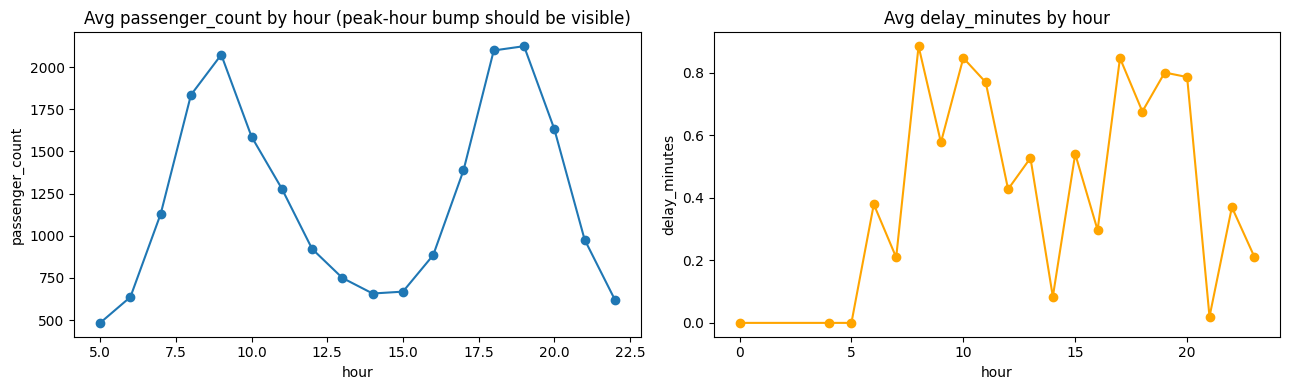

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
crowd_df.groupby("hour")["passenger_count"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Avg passenger_count by hour (peak-hour bump should be visible)")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("passenger_count")

delay_df.groupby("hour")["delay_minutes"].mean().plot(ax=axes[1], marker="o", color="orange")
axes[1].set_title("Avg delay_minutes by hour")
axes[1].set_xlabel("hour"); axes[1].set_ylabel("delay_minutes")
plt.tight_layout()
plt.show()

In [5]:
import time
import joblib
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from xgboost import XGBRegressor


RF_SEARCH_SPACE = {
    "n_estimators": [75, 100, 150, 200],
    "max_depth": [6, 8, 10, 12],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", 0.5, 0.8, 1.0],
}
XGB_SEARCH_SPACE = {
    "n_estimators": [150, 200, 300, 400, 600],
    "max_depth": [4, 5, 6, 7, 8],
    "learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
}


SEARCH_SAMPLE_CAP = 120_000

def baseline_candidates():
    return {
        "random_forest": RandomForestRegressor(n_estimators=60, max_depth=8, random_state=42, n_jobs=-1),
        "xgboost": XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, random_state=42,
            objective="reg:squarederror", n_jobs=-1,
        ),
    }

def tuned_search(name, X_train, y_train, n_iter=20, cv=5):

    if len(X_train) > SEARCH_SAMPLE_CAP:
        X_search, _, y_search, _ = train_test_split(
            X_train, y_train, train_size=SEARCH_SAMPLE_CAP, random_state=42
        )
    else:
        X_search, y_search = X_train, y_train

    if name == "random_forest":

        base = RandomForestRegressor(random_state=42, n_jobs=1)
        space = RF_SEARCH_SPACE
    else:

        base = XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=1)
        space = XGB_SEARCH_SPACE

    search = RandomizedSearchCV(
        base, space, n_iter=n_iter, cv=cv, scoring="neg_mean_absolute_error",
        random_state=42, n_jobs=-1, verbose=1,
    )
    t0 = time.time()
    search.fit(X_search, y_search)
    print(f"    {name} search done on {len(X_search)} rows in {time.time() - t0:.0f}s -> refitting best params on full {len(X_train)}-row training set")

    best_params = search.best_params_
    if name == "random_forest":
        final_model = RandomForestRegressor(random_state=42, n_jobs=-1, **best_params)
    else:
        final_model = XGBRegressor(random_state=42, objective="reg:squarederror", n_jobs=-1, **best_params)
    final_model.fit(X_train, y_train)
    return final_model, best_params

def train_and_compare(df, features, target, with_mape=False, tune=True, search_iter=20, search_cv=5):
    X, y = df[features], df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    results = {}
    for name, model in baseline_candidates().items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        results[name] = {
            "model": model, "params": model.get_params(),
            "mae": mean_absolute_error(y_test, pred),
            "rmse": mean_squared_error(y_test, pred) ** 0.5,
            "r2": r2_score(y_test, pred),
        }
        if with_mape:
            results[name]["mape"] = mean_absolute_percentage_error(y_test, pred)

    if tune:
        for base_name in ["random_forest", "xgboost"]:
            tuned_name = f"{base_name}_tuned"
            try:
                best_est, best_params = tuned_search(base_name, X_train, y_train, n_iter=search_iter, cv=search_cv)
            except KeyboardInterrupt:

                print(f"    {tuned_name}: search interrupted - keeping baseline {base_name} only")
                continue
            pred = best_est.predict(X_test)
            results[tuned_name] = {
                "model": best_est, "params": best_params,
                "mae": mean_absolute_error(y_test, pred),
                "rmse": mean_squared_error(y_test, pred) ** 0.5,
                "r2": r2_score(y_test, pred),
            }
            if with_mape:
                results[tuned_name]["mape"] = mean_absolute_percentage_error(y_test, pred)

    best_name = min(results, key=lambda n: results[n]["mae"])
    return best_name, results

def report(name, best, results, with_mape=False):
    print(f"\n=== {name} - winner: {best} ===")
    for cand, r in sorted(results.items(), key=lambda kv: kv[1]["mae"]):
        marker = "  <- selected" if cand == best else ""
        line = f"  {cand:22s} MAE={r['mae']:.3f}  RMSE={r['rmse']:.3f}  R2={r['r2']:.3f}"
        if with_mape:
            line += f"  MAPE={r['mape']:.2%}" if r['mape'] < 100 else "  MAPE=unstable(near-zero targets)"
        print(line + marker)

CROWD_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour"]
DELAY_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour",
                   "passenger_count", "capacity_passengers", "train_age_days", "weather_code"]
FREQ_FEATURES = ["station_id", "hour", "day_of_week", "is_weekend", "is_peak_hour"]
MIN_FREQUENCY, MAX_FREQUENCY = 3, 15
print("Training functions ready.")


Training functions ready.


In [6]:
print("Training crowd model (baseline + tuned search)...")
crowd_best, crowd_results = train_and_compare(crowd_df, CROWD_FEATURES, "passenger_count", with_mape=True)
report("Crowd model", crowd_best, crowd_results, with_mape=True)

metrics = {k: v for k, v in crowd_results[crowd_best].items() if k not in ("model", "params")}
joblib.dump({
    "model": crowd_results[crowd_best]["model"],
    "model_name": crowd_best,
    "metrics": metrics,
    "features": CROWD_FEATURES,
}, "crowd_model.pkl")
print("Saved crowd_model.pkl")


Training crowd model (baseline + tuned search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    random_forest search done on 37296 rows in 237s -> refitting best params on full 37296-row training set
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    xgboost search done on 37296 rows in 84s -> refitting best params on full 37296-row training set

=== Crowd model - winner: xgboost_tuned ===
  xgboost_tuned          MAE=279.861  RMSE=923.135  R2=0.840  MAPE=unstable(near-zero targets)  <- selected
  random_forest_tuned    MAE=342.030  RMSE=837.094  R2=0.869  MAPE=unstable(near-zero targets)
  xgboost                MAE=382.515  RMSE=909.975  R2=0.845  MAPE=unstable(near-zero targets)
  random_forest          MAE=429.729  RMSE=1003.940  R2=0.811  MAPE=unstable(near-zero targets)
Saved crowd_model.pkl


In [7]:
print("Training delay model (baseline + tuned search)...")
delay_best, delay_results = train_and_compare(delay_df, DELAY_FEATURES, "delay_minutes")
report("Delay model", delay_best, delay_results)

metrics = {k: v for k, v in delay_results[delay_best].items() if k not in ("model", "params")}
joblib.dump({
    "model": delay_results[delay_best]["model"],
    "model_name": delay_best,
    "metrics": metrics,
    "features": DELAY_FEATURES,
}, "delay_model.pkl")
print("Saved delay_model.pkl")


Training delay model (baseline + tuned search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    random_forest search done on 120000 rows in 1398s -> refitting best params on full 301027-row training set
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    xgboost search done on 120000 rows in 280s -> refitting best params on full 301027-row training set

=== Delay model - winner: random_forest_tuned ===
  random_forest_tuned    MAE=0.455  RMSE=1.085  R2=0.393  <- selected
  random_forest          MAE=0.456  RMSE=1.083  R2=0.395
  xgboost_tuned          MAE=0.456  RMSE=1.087  R2=0.391
  xgboost                MAE=0.457  RMSE=1.085  R2=0.392
Saved delay_model.pkl


In [8]:
print("Training frequency model (baseline + tuned search)...")
freq_best, freq_results = train_and_compare(freq_df, FREQ_FEATURES, "recommended_frequency_minutes")
report("Frequency model", freq_best, freq_results)

metrics = {k: v for k, v in freq_results[freq_best].items() if k not in ("model", "params")}
joblib.dump({
    "model": freq_results[freq_best]["model"],
    "features": FREQ_FEATURES,
    "model_name": freq_best,
    "metrics": metrics,
    "min_frequency": MIN_FREQUENCY,
    "max_frequency": MAX_FREQUENCY,
}, "frequency_model.pkl")
print("Saved frequency_model.pkl")

for label, best, results in [("Crowd", crowd_best, crowd_results), ("Delay", delay_best, delay_results), ("Frequency", freq_best, freq_results)]:
    baseline_mae = min(results[n]["mae"] for n in results if n in ("random_forest", "xgboost"))
    won_mae = results[best]["mae"]
    if won_mae < baseline_mae:
        gain = 100 * (baseline_mae - won_mae) / baseline_mae
        print(f"{label}: tuning improved MAE by {gain:.1f}% over the best fixed-hyperparameter baseline ({baseline_mae:.3f} -> {won_mae:.3f})")
    else:
        print(f"{label}: tuning found nothing better than the baseline - baseline ({best}) wins, MAE={won_mae:.3f}")


Training frequency model (baseline + tuned search)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    random_forest search done on 37296 rows in 228s -> refitting best params on full 37296-row training set
Fitting 5 folds for each of 20 candidates, totalling 100 fits
    xgboost search done on 37296 rows in 82s -> refitting best params on full 37296-row training set

=== Frequency model - winner: xgboost_tuned ===
  xgboost_tuned          MAE=0.153  RMSE=0.496  R2=0.837  <- selected
  random_forest_tuned    MAE=0.186  RMSE=0.446  R2=0.868
  xgboost                MAE=0.207  RMSE=0.480  R2=0.847
  random_forest          MAE=0.233  RMSE=0.534  R2=0.811
Saved frequency_model.pkl
Crowd: tuning improved MAE by 26.8% over the best fixed-hyperparameter baseline (382.515 -> 279.861)
Delay: tuning improved MAE by 0.2% over the best fixed-hyperparameter baseline (0.456 -> 0.455)
Frequency: tuning improved MAE by 25.9% over the best fixed-hyperparameter baseline (0.207 -> 0.153)

In [9]:
samples = {
    "crowd_model.pkl":     [[1, 9, 1, 0, 1]],
    "frequency_model.pkl": [[1, 9, 1, 0, 1]],
    "delay_model.pkl":     [[1, 9, 1, 0, 1, 500, 1200, 800, 0]],
}
for name, sample in samples.items():
    bundle = joblib.load(name)
    pred = bundle["model"].predict(pd.DataFrame(sample, columns=bundle["features"]))
    print(f"{name:20s} model={bundle['model_name']:14s} sample_prediction={pred[0]:.2f}")

crowd_model.pkl      model=xgboost_tuned  sample_prediction=20272.18
frequency_model.pkl  model=xgboost_tuned  sample_prediction=4.21
delay_model.pkl      model=random_forest_tuned sample_prediction=0.52


In [11]:
import zipfile

with zipfile.ZipFile("metroflow_models.zip", "w") as zf:
    for f in ["crowd_model.pkl", "delay_model.pkl", "frequency_model.pkl"]:
        zf.write(f)

if IN_COLAB:
    files.download("metroflow_models.zip")
else:
    print("Saved metroflow_models.zip next to this notebook.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>